# Acoustic scattering · geometry × sources

Exploratory multiparameter analysis of The Well `acoustic_scattering_maze` feature table.

**Not ANOVA** — response surfaces, interaction plots, tables, and spectral slope as a frequency-content proxy.


In [1]:
from pathlib import Path
import sys
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#5F6B45", "#9A7340", "#3D5A56", "#7A3E32", "#5C574E", "#8A9470"]
sns.set_palette(PALETTE)
%matplotlib inline

from src.dataset_catalog import get_dataset

spec = get_dataset("acoustic_scattering")
df = pd.read_parquet(spec.feature_path)
print("rows:", len(df), "| synthetic:", bool(df["synthetic"].any()) if "synthetic" in df.columns else "n/a")
print("maze_width levels:", sorted(df["maze_width"].unique()))
print("n_sources levels:", sorted(df["n_sources"].unique()))
df.head()


rows: 12 | synthetic: False
maze_width levels: [np.int64(12), np.int64(14), np.int64(16)]
n_sources levels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,split,file,traj_idx,replicate,maze_width,n_sources,mean_abs_pressure,pressure_energy,kinetic_energy,wall_fraction,spectral_slope,time_to_steady,n_timesteps_used,spatial_resolution_used,synthetic,injected_anomaly
0,train,acoustic_scattering_maze_chunk_0.hdf5,0,0,12,1,0.036836,0.013767,0.000525,0.652344,-0.389981,0.96,26,16,False,False
1,train,acoustic_scattering_maze_chunk_0.hdf5,1,1,12,1,0.050973,0.017015,0.000691,0.652344,-1.272715,0.96,26,16,False,False
2,train,acoustic_scattering_maze_chunk_0.hdf5,2,2,12,1,0.042833,0.018002,0.000606,0.652344,-0.547649,1.00,26,16,False,False
3,train,acoustic_scattering_maze_chunk_1.hdf5,0,0,14,1,0.097854,0.043649,0.001528,0.531250,-0.154574,0.96,26,16,False,False
4,train,acoustic_scattering_maze_chunk_1.hdf5,1,1,14,1,0.033517,0.008591,0.000453,0.531250,-0.082003,1.00,26,16,False,False


## Coverage table

In [2]:

coverage = (
    df.groupby(["maze_width", "n_sources"], as_index=False)
    .size()
    .rename(columns={"size": "n_traj"})
    .sort_values(["maze_width", "n_sources"])
)
display(coverage)
print(f"Cells occupied: {len(coverage)} | total traj: {coverage['n_traj'].sum()}")


,maze_width,n_sources,n_traj
0,12,1,3
1,14,1,4
2,14,3,1
3,14,4,1
4,16,2,2
5,16,3,1


Cells occupied: 6 | total traj: 12


## Feature dictionary

In [3]:

desc = {
    "maze_width": "path width (px) — geometry factor",
    "n_sources": "initial high-pressure rings",
    "mean_abs_pressure": "mean |p| over space/time",
    "pressure_energy": "mean p² (energy proxy)",
    "kinetic_energy": "mean ½|u|²",
    "wall_fraction": "fraction of dense-wall cells",
    "spectral_slope": "frequency-content proxy of pressure",
    "time_to_steady": "fraction of run until |p| plateaus",
}
pd.DataFrame({"column": list(desc), "meaning": list(desc.values())})


,column,meaning
0,maze_width,path width (px) — geometry factor
1,n_sources,initial high-pressure rings
2,mean_abs_pressure,mean |p| over space/time
3,pressure_energy,mean p² (energy proxy)
4,kinetic_energy,mean ½|u|²
5,wall_fraction,fraction of dense-wall cells
6,spectral_slope,frequency-content proxy of pressure
7,time_to_steady,fraction of run until |p| plateaus


## Summary statistics

In [4]:

metrics = [c for c in [
    "mean_abs_pressure", "pressure_energy", "kinetic_energy",
    "wall_fraction", "spectral_slope", "time_to_steady",
] if c in df.columns]

display(df[metrics].describe().T.round(4))

by_width = df.groupby("maze_width")[metrics].agg(["mean", "std"]).round(4)
display(by_width)

by_src = df.groupby("n_sources")[metrics].agg(["mean", "std"]).round(4)
display(by_src)


,count,mean,std,min,25%,50%,75%,max
mean_abs_pressure,12.0,0.0580,0.0210,0.0335,0.0428,0.0505,0.0669,0.0979
pressure_energy,12.0,0.0252,0.0135,0.0086,0.0162,0.0222,0.0290,0.0547
kinetic_energy,12.0,0.0009,0.0004,0.0005,0.0006,0.0007,0.0010,0.0018
wall_fraction,12.0,0.5732,0.0633,0.5000,0.5234,0.5703,0.6201,0.6523
spectral_slope,12.0,-0.3055,0.8588,-1.3489,-0.9683,-0.2723,-0.0239,1.4471
time_to_steady,12.0,0.9800,0.0209,0.9600,0.9600,0.9800,1.0000,1.0000


mean_abs_pressure         pressure_energy         kinetic_energy  \
                        mean     std            mean     std           mean   
maze_width                                                                    
12                    0.0435  0.0071          0.0163  0.0022         0.0006   
14                    0.0682  0.0251          0.0297  0.0180         0.0011   
16                    0.0521  0.0106          0.0251  0.0028         0.0007   

                   wall_fraction         spectral_slope          \
               std          mean     std           mean     std   
maze_width                                                        
12          0.0001        0.6523  0.0000        -0.7368  0.4708   
14          0.0005        0.5703  0.0428        -0.1146  0.6955   
16          0.0002        0.5000  0.0000        -0.2562  1.4947   

           time_to_steady          
                     mean     std  
maze_width                         
12                 0.9733  0.0231  
14                 0.9800  0.0219  
16                 0.9867  0.0231

mean_abs_pressure         pressure_energy         kinetic_energy  \
                       mean     std            mean     std           mean   
n_sources                                                                    
1                    0.0531  0.0218          0.0196  0.0115         0.0008   
2                    0.0531  0.0147          0.0267  0.0001         0.0007   
3                    0.0708  0.0293          0.0383  0.0232         0.0012   
4                    0.0769     NaN          0.0354     NaN         0.0010   

                  wall_fraction         spectral_slope         time_to_steady  \
              std          mean     std           mean     std           mean   
n_sources                                                                       
1          0.0004        0.5943  0.0609        -0.2492  0.6341         0.9771   
2          0.0003        0.5000  0.0000        -1.1079  0.3410         0.9800   
3          0.0008        0.5547  0.0773         0.0718  1.9449         0.9800   
4             NaN        0.6094     NaN         0.1503     NaN         1.0000   

                   
              std  
n_sources          
1          0.0214  
2          0.0283  
3          0.0283  
4             NaN

## Cell-mean response table (geometry × sources)

In [5]:

cell = (
    df.groupby(["maze_width", "n_sources"], as_index=False)[metrics]
    .mean()
    .sort_values(["maze_width", "n_sources"])
)
display(cell.round(4))


,maze_width,n_sources,mean_abs_pressure,pressure_energy,kinetic_energy,wall_fraction,spectral_slope,time_to_steady
0,12,1,0.0435,0.0163,0.0006,0.6523,-0.7368,0.9733
1,14,1,0.0602,0.0220,0.0009,0.5508,0.1164,0.9800
2,14,3,0.0915,0.0547,0.0018,0.6094,-1.3035,0.9600
3,14,4,0.0769,0.0354,0.0010,0.6094,0.1503,1.0000
4,16,2,0.0531,0.0267,0.0007,0.5000,-1.1079,0.9800
5,16,3,0.0501,0.0219,0.0007,0.5000,1.4471,1.0000


## Response-surface heatmaps

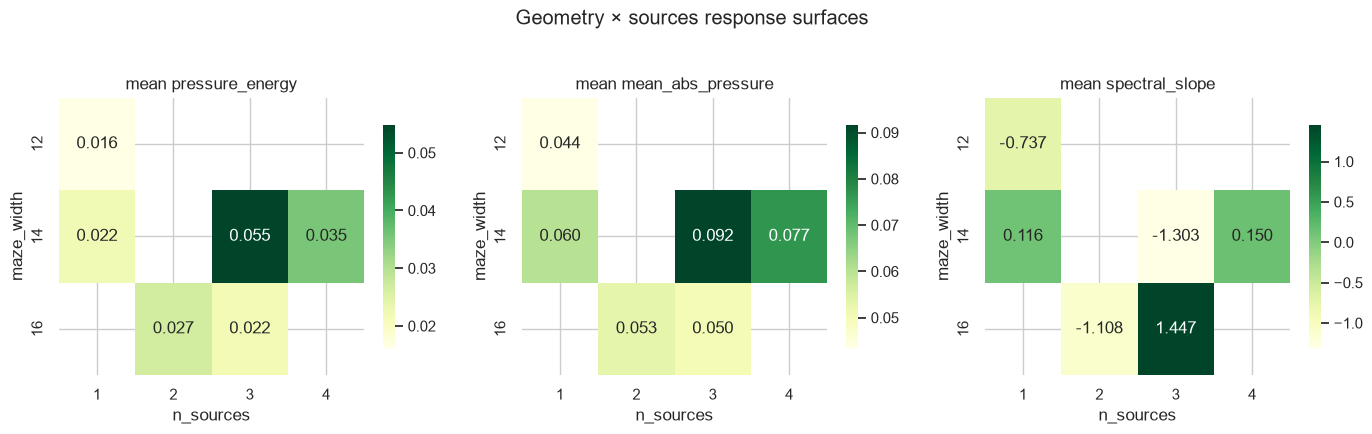

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, metric in zip(axes, ["pressure_energy", "mean_abs_pressure", "spectral_slope"]):
    piv = cell.pivot(index="maze_width", columns="n_sources", values=metric)
    sns.heatmap(piv, annot=True, fmt=".3f", cmap="YlGn", ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"mean {metric}")
    ax.set_xlabel("n_sources"); ax.set_ylabel("maze_width")
plt.suptitle("Geometry × sources response surfaces", y=1.03)
plt.tight_layout(); plt.show()


## Interaction plots

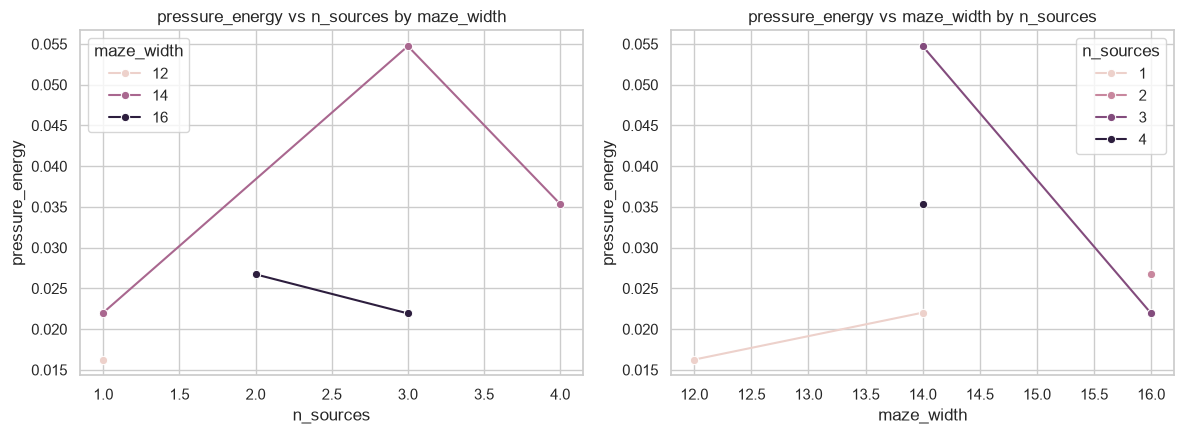

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(
    data=cell, x="n_sources", y="pressure_energy",
    hue="maze_width", marker="o", ax=axes[0],
)
axes[0].set_title("pressure_energy vs n_sources by maze_width")

sns.lineplot(
    data=cell, x="maze_width", y="pressure_energy",
    hue="n_sources", marker="o", ax=axes[1],
)
axes[1].set_title("pressure_energy vs maze_width by n_sources")
plt.tight_layout(); plt.show()


## Distributions & scatter relationships

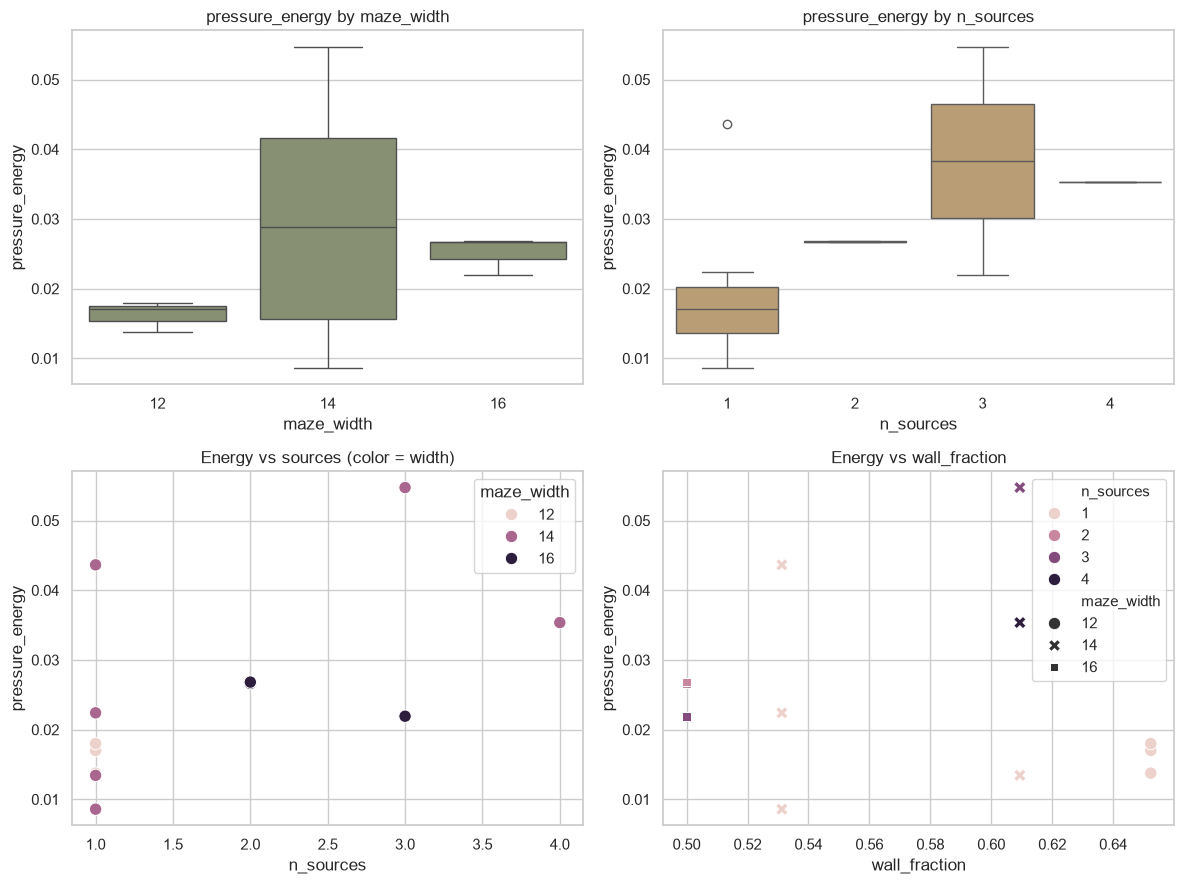

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.boxplot(data=df, x="maze_width", y="pressure_energy", ax=axes[0, 0], color="#8A9470")
axes[0, 0].set_title("pressure_energy by maze_width")

sns.boxplot(data=df, x="n_sources", y="pressure_energy", ax=axes[0, 1], color="#C4A06A")
axes[0, 1].set_title("pressure_energy by n_sources")

sns.scatterplot(
    data=df, x="n_sources", y="pressure_energy",
    hue="maze_width", s=80, ax=axes[1, 0],
)
axes[1, 0].set_title("Energy vs sources (color = width)")

sns.scatterplot(
    data=df, x="wall_fraction", y="pressure_energy",
    hue="n_sources", style="maze_width", s=80, ax=axes[1, 1],
)
axes[1, 1].set_title("Energy vs wall_fraction")
plt.tight_layout(); plt.show()


## Frequency-content proxy (spectral slope)

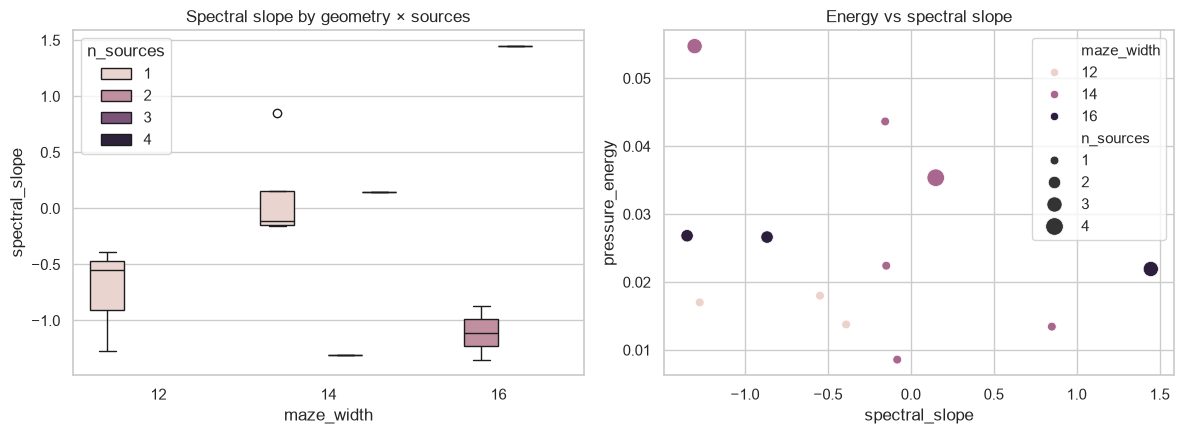

count    mean     std
maze_width n_sources                       
12         1              3 -0.7368  0.4708
14         1              4  0.1164  0.4903
           3              1 -1.3035     NaN
           4              1  0.1503     NaN
16         2              2 -1.1079  0.3410
           3              1  1.4471     NaN

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=df, x="maze_width", y="spectral_slope", hue="n_sources", ax=axes[0])
axes[0].set_title("Spectral slope by geometry × sources")

sns.scatterplot(
    data=df, x="spectral_slope", y="pressure_energy",
    hue="maze_width", size="n_sources", sizes=(40, 160), ax=axes[1],
)
axes[1].set_title("Energy vs spectral slope")
plt.tight_layout(); plt.show()

slope_tab = (
    df.groupby(["maze_width", "n_sources"])["spectral_slope"]
    .agg(["count", "mean", "std"])
    .round(4)
)
display(slope_tab)


## Spearman correlations

,maze_width,n_sources,wall_fraction,mean_abs_pressure,pressure_energy,kinetic_energy,spectral_slope,time_to_steady
maze_width,1.000,0.593,-0.949,0.171,0.376,0.068,0.102,0.236
n_sources,0.593,1.000,-0.387,0.388,0.615,0.321,-0.012,0.216
wall_fraction,-0.949,-0.387,1.000,-0.108,-0.302,-0.043,-0.108,-0.149
mean_abs_pressure,0.171,0.388,-0.108,1.000,0.832,0.937,-0.189,-0.483
pressure_energy,0.376,0.615,-0.302,0.832,1.000,0.755,-0.357,-0.338
kinetic_energy,0.068,0.321,-0.043,0.937,0.755,1.000,-0.119,-0.531
spectral_slope,0.102,-0.012,-0.108,-0.189,-0.357,-0.119,1.000,0.579
time_to_steady,0.236,0.216,-0.149,-0.483,-0.338,-0.531,0.579,1.000


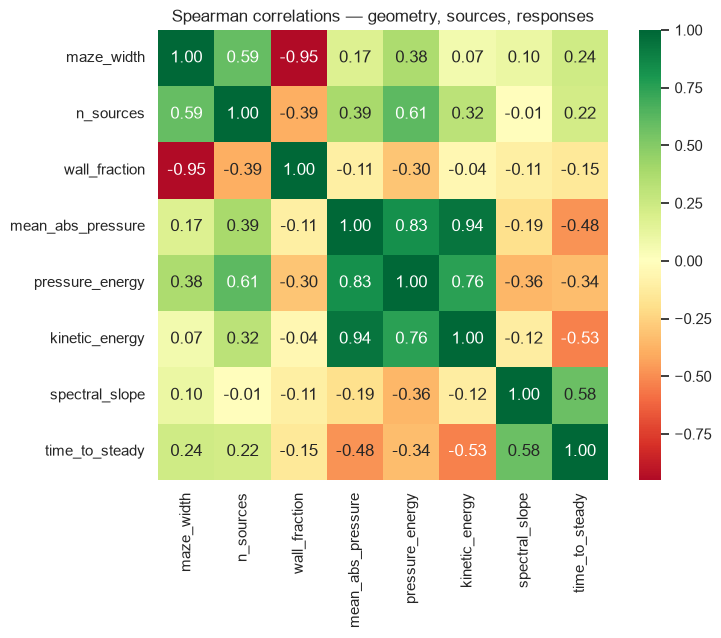

In [10]:

num = list(dict.fromkeys(
    c for c in ["maze_width", "n_sources", "wall_fraction", *metrics] if c in df.columns
))
corr = df[num].corr(method="spearman")
display(corr.round(3))

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, square=True)
plt.title("Spearman correlations — geometry, sources, responses")
plt.tight_layout(); plt.show()


## Pairplot of key responses

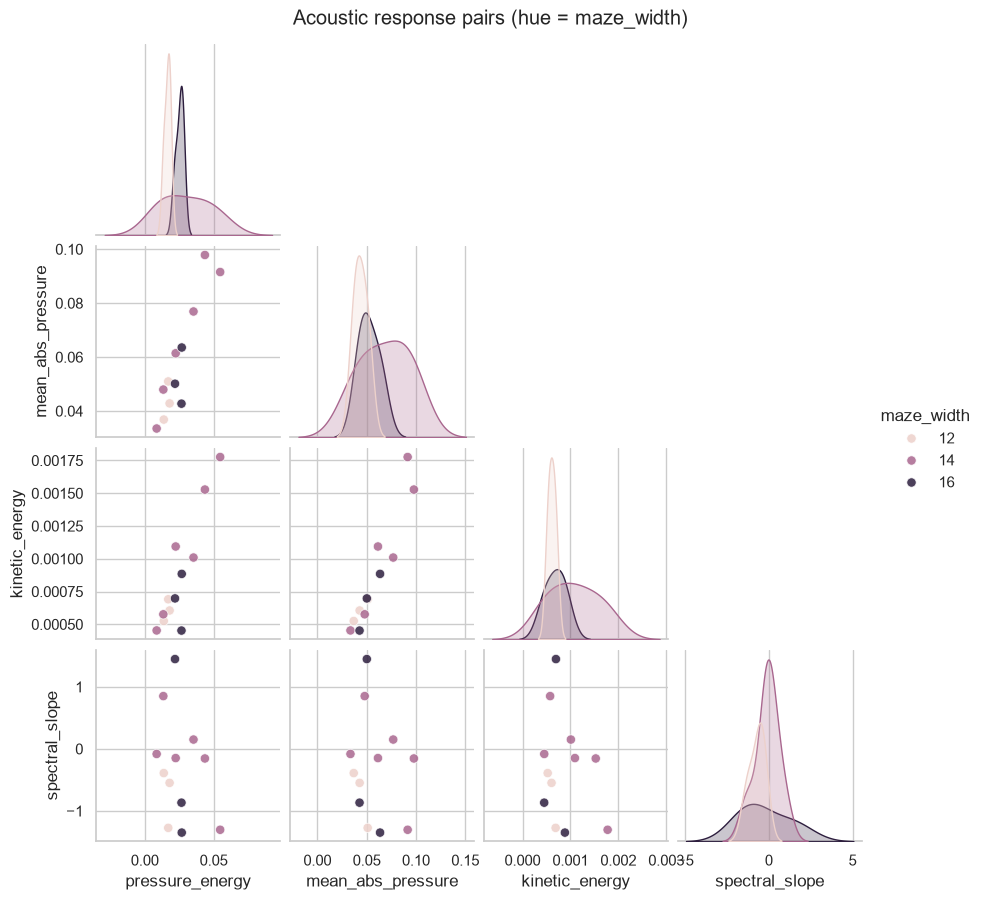

In [11]:

pair_cols = [c for c in [
    "pressure_energy", "mean_abs_pressure", "kinetic_energy", "spectral_slope"
] if c in df.columns]
g = sns.pairplot(
    df, vars=pair_cols, hue="maze_width", corner=True, height=2.2,
    plot_kws={"s": 45, "alpha": 0.85},
)
g.fig.suptitle("Acoustic response pairs (hue = maze_width)", y=1.02)
plt.show()


## Takeaway

Geometry and source count **jointly** shape pressure energy; non-parallel interaction curves signal multiparameter structure. Spectral slope tracks how scattering redistributes spatial-frequency content across the maze.
